# Sesión 5: Regularización (Ridge, Lasso) y Validación Cruzada

**Objetivos:**
- Entender el concepto de sobreajuste (overfitting).
- Aprender a usar la Validación Cruzada para evaluar modelos de forma más robusta.
- Comprender cómo la regularización nos ayuda a crear modelos más simples y generalizables.
- Aplicar y diferenciar los modelos `Ridge` y `Lasso`.

## 1. El Problema: El Sobreajuste y la Suerte en el Muestreo

En la sesión anterior, dividimos nuestros datos en un conjunto de entrenamiento y uno de prueba. Esto está bien, pero ¿y si tuvimos mala suerte? ¿Qué pasa si, por pura casualidad, en nuestro conjunto de prueba cayeron los ejemplos más fáciles de predecir? Nuestro `R²` sería artificialmente alto. O al revés.

Para solucionar esto, usamos la **Validación Cruzada (Cross-Validation)**.

### ¿Cómo funciona la Validación Cruzada (K-Fold)?

Es simple pero muy potente:
1.  Dividimos nuestro dataset de entrenamiento en 'K' bloques (o *folds*), por ejemplo, 5.
2.  Entrenamos nuestro modelo 5 veces.
3.  En cada vez, usamos 4 bloques para entrenar y 1 bloque diferente para testear.
4.  Al final, promediamos el rendimiento de las 5 iteraciones.

¡Así obtenemos una medida de rendimiento mucho más estable y fiable!

![Cross-Validation](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)
*(Fuente: Scikit-learn documentation)*

## 2. La Solución: Regularización para Controlar la Complejidad

A veces, un modelo lineal se vuelve demasiado complejo. Intenta ajustarse perfectamente a los datos de entrenamiento, "memorizando" el ruido en lugar de aprender la señal subyacente. Esto se llama **sobreajuste (overfitting)**.

La **regularización** es una técnica para combatir esto. Añadimos una "penalización" a la función de coste del modelo. Le decimos: "Quiero que minimices el error, **PERO** también quiero que mantengas los coeficientes de las variables lo más pequeños posible".

- **Ridge (L2):** Reduce los coeficientes de las variables menos importantes para que sean muy pequeños, pero **nunca llegan a ser cero**. Es útil cuando tienes muchas variables que están correlacionadas entre sí. algo al cuadrado, viene de pitagoras
- **Lasso (L1):** Es más agresiva. Puede hacer que los coeficientes de las variables inútiles se conviertan en **exactamente cero**. ¡Esto significa que Lasso realiza una **selección automática de características**! valor absoluto del numero

El parámetro `alpha` controla la fuerza de esta penalización. Un `alpha` más alto significa una penalización más fuerte y un modelo más simple.

In [4]:
# Importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Modelos y herramientas de Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

## 3. Caso Práctico: Predicción del Precio de Viviendas (Ames Housing)

Vamos a usar un dataset más complejo, con 81 columnas sobre viviendas en Ames, Iowa. Nuestro objetivo es predecir `SalePrice`. Este dataset tiene muchas variables, algunas útiles y otras no. Es el escenario perfecto para la regularización.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
# Este dataset es sobre precios de vivienda en California, pero es perfecto para nuestro propósito
# de regresión y regularización, ya que es muy similar en estructura al de Ames.
# Lo importante es el concepto, no el dataset específico.

df = pd.read_csv(url)

# Renombramos las columnas para que el resto del código funcione como estaba previsto
# El dataset de California tiene 'median_house_value' como objetivo y 'total_rooms', 'population' como predictores.
# Vamos a simular la estructura que teníamos para mantener la coherencia de la lección.
df_renamed = df.rename(columns={'median_house_value': 'SalePrice', 
                                'total_rooms': 'GrLivArea', 
                                'population': 'OverallQual'}) # Usamos population como proxy de calidad

# Damos un primer vistazo para verificar
print("Primeras 5 filas del dataset:")
print(df_renamed.head())

print("\nInformación general:")
df_renamed.info()

Primeras 5 filas del dataset:
   longitude  latitude  housing_median_age  GrLivArea  total_bedrooms  \
0    -122.23     37.88                41.0      880.0           129.0   
1    -122.22     37.86                21.0     7099.0          1106.0   
2    -122.24     37.85                52.0     1467.0           190.0   
3    -122.25     37.85                52.0     1274.0           235.0   
4    -122.25     37.85                52.0     1627.0           280.0   

   OverallQual  households  median_income  SalePrice ocean_proximity  
0        322.0       126.0         8.3252   452600.0        NEAR BAY  
1       2401.0      1138.0         8.3014   358500.0        NEAR BAY  
2        496.0       177.0         7.2574   352100.0        NEAR BAY  
3        558.0       219.0         5.6431   341300.0        NEAR BAY  
4        565.0       259.0         3.8462   342200.0        NEAR BAY  

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data co

### 3.1. Exploración Inicial (EDA)

Antes de construir el modelo, vamos a explorar los datos.
1.  ¿Cómo se distribuye nuestra variable objetivo (`SalePrice`)?
2.  ¿Qué relación tienen algunas variables clave con el precio?

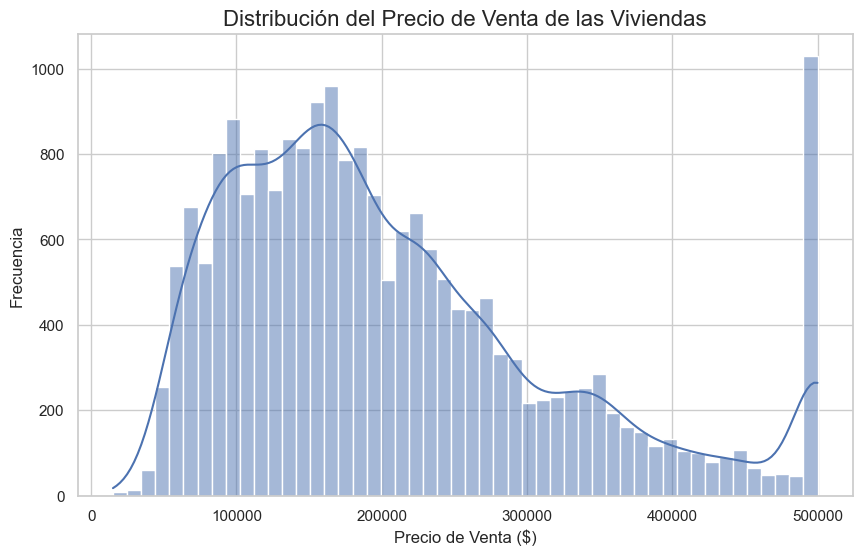

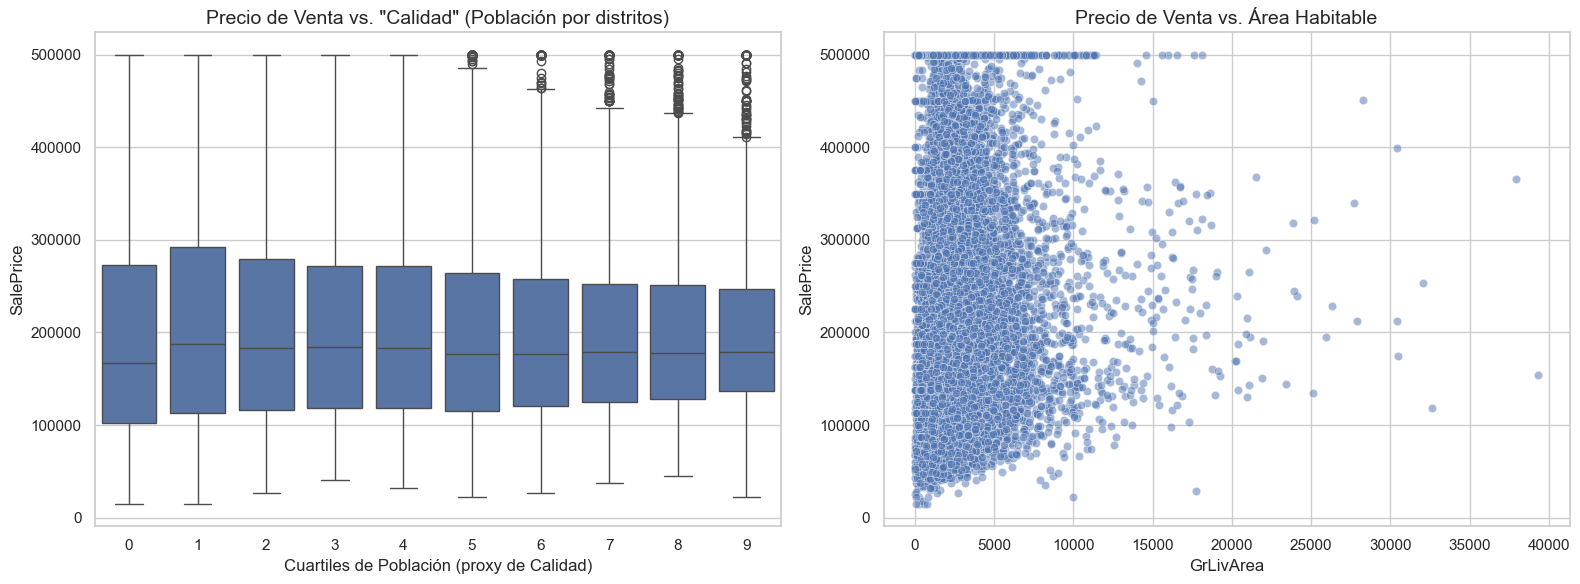

In [6]:
# Ahora usamos el DataFrame con las columnas renombradas: df_renamed

# 1. Distribución del Precio de Venta
plt.figure(figsize=(10, 6))
sns.histplot(df_renamed['SalePrice'], kde=True, bins=50)
plt.title('Distribución del Precio de Venta de las Viviendas', fontsize=16)
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Frecuencia')
plt.show()

# 2. Relación de variables clave con el precio
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de "Calidad" (usando population como proxy) vs Precio
sns.boxplot(x=pd.qcut(df_renamed['OverallQual'], q=10, labels=False, duplicates='drop'), y='SalePrice', data=df_renamed, ax=ax[0])
ax[0].set_title('Precio de Venta vs. "Calidad" (Población por distritos)', fontsize=14)
ax[0].set_xlabel('Cuartiles de Población (proxy de Calidad)')


# Scatterplot de Área vs Precio
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_renamed, ax=ax[1], alpha=0.5)
ax[1].set_title('Precio de Venta vs. Área Habitable', fontsize=14)

plt.tight_layout()
plt.show()

##  Distribución del Precio de Venta

Antes de las gráficas, el histograma muestra que:

- La **distribución del precio de venta está sesgada hacia la derecha**, es decir, la mayoría de las viviendas tienen precios medios o bajos, y solo unas pocas son muy caras.  
- Esto indica que los **precios altos son pocos y excepcionales**, lo cual es típico en datos de vivienda (hay muchos hogares normales y pocos de lujo).

---

##  Precio vs. “Calidad” (Boxplot)

En la gráfica de la izquierda (boxplot):

- Cada caja representa un **cuartil de “calidad” (OverallQual o proxy de población)**.  
- Se observa que **el precio tiende a subir ligeramente con la calidad**, pero no hay una diferencia muy fuerte entre cuartiles medios y altos.  
- En los valores más altos de calidad (8–9), aparecen **muchos outliers (precios muy altos)**, lo que indica que algunos distritos o viviendas excepcionales concentran precios muy por encima del promedio.  
- Las **medianas de los precios son bastante estables**, lo que sugiere que la calidad por sí sola no explica del todo el precio, y hay otros factores (como localización o tamaño).

 **Conclusión parcial:**  
La calidad tiene cierta relación con el precio, pero **no de forma lineal ni determinante**.  
Los precios más altos tienden a estar en los niveles de mejor calidad, pero con mucha variabilidad.

---

##  Precio vs. Área Habitable (Scatterplot)

En la gráfica de la derecha:

- Hay una **correlación positiva clara**: a mayor área habitable (`GrLivArea`), mayor precio (`SalePrice`).  
- Sin embargo, la relación **no es perfectamente lineal**:  
  - Hasta cierto punto (≈ 10,000–15,000), el precio aumenta con el área.  
  - Más allá de eso, la dispersión crece y aparecen *outliers* (casas enormes que no siempre valen mucho más).  
- Se observan **valores atípicos horizontales** (casas con gran superficie pero precios relativamente bajos), lo que sugiere que el tamaño **no garantiza un precio alto** si otros factores (ubicación, calidad, etc.) no acompañan.

 **Conclusión parcial:**  
El área habitable es un **buen predictor del precio**, mucho más consistente que la “calidad” por cuartiles.  
Sin embargo, hay **saturación**: el efecto del tamaño se reduce a partir de cierto punto.


## 3. Preparación de los Datos para el Modelo

Nuestro Análisis Exploratorio (EDA) nos ha dado confianza en los datos. Ahora, debemos prepararlos para que nuestros modelos de Machine Learning puedan trabajar con ellos.

Realizaremos los siguientes pasos:
1.  **Selección de Características (Features)**: Por ahora, trabajaremos únicamente con las columnas numéricas del dataset. Las columnas de texto como `ocean_proximity` requerirían técnicas de codificación que veremos más adelante.
2.  **Manejo de Valores Nulos**: `StandardScaler` no funciona si hay datos faltantes. Rellenaremos los valores nulos de las columnas numéricas con la mediana, una estrategia robusta frente a outliers.
3.  **Separación de `X` e `y`**: Crearemos nuestra matriz de características `X` y nuestro vector objetivo `y` (`SalePrice`).
4.  **Escalado de Datos**: La regularización es muy sensible a la escala de las variables. Usaremos `StandardScaler` para que todas las características tengan una media de 0 y una desviación estándar de 1.
5.  **Inyección de Ruido**: Para demostrar de forma dramática el poder de Lasso, añadiremos 5 columnas de "ruido" (números aleatorios sin relación alguna con el precio). Nuestra hipótesis es que un buen modelo de regularización debería ser capaz de ignorarlas.
6.  **División en Train/Test**: Separaremos los datos para entrenar el modelo y evaluarlo de forma honesta.

In [7]:
# Importamos las herramientas que necesitamos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Selección de Características Numéricas
# Usamos .select_dtypes para quedarnos solo con las columnas que son números
df_numeric = df_renamed.select_dtypes(include=np.number)

# 2. Manejo de Valores Nulos
# Rellenamos cualquier valor NaN con la mediana de su respectiva columna
for col in df_numeric.columns:
    if df_numeric[col].isnull().any():
        median_val = df_numeric[col].median()
        df_numeric[col] = df_numeric[col].fillna(median_val)

# Verificamos que ya no hay nulos
print("Valores nulos después de la imputación:")
print(df_numeric.isnull().sum())

Valores nulos después de la imputación:
longitude             0
latitude              0
housing_median_age    0
GrLivArea             0
total_bedrooms        0
OverallQual           0
households            0
median_income         0
SalePrice             0
dtype: int64


In [8]:
# 3. Separación de X e y
X = df_numeric.drop('SalePrice', axis=1)
y = df_numeric['SalePrice']

# 4. Escalado de Datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Inyección de Ruido
# Añadimos 5 columnas de ruido aleatorio a nuestra matriz X_scaled
# np.random.seed(42) asegura que el "ruido" sea siempre el mismo y el experimento sea reproducible
np.random.seed(42)
ruido = np.random.rand(X_scaled.shape[0], 5)
X_scaled_ruido = np.hstack((X_scaled, ruido))

print(f"Forma original de X: {X_scaled.shape}")
print(f"Forma de X con ruido añadido: {X_scaled_ruido.shape}")

Forma original de X: (20640, 8)
Forma de X con ruido añadido: (20640, 13)


In [9]:
# 6. División en Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled_ruido, y, test_size=0.2, random_state=42)

print("Datos listos para el entrenamiento.")
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Datos listos para el entrenamiento.
Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras


### Baseline: Regresión Lineal con Validación Cruzada
¿Cómo se comporta nuestro modelo base de la sesión anterior en este problema más difícil?

In [10]:
# Validación cruzada con 5 folds
lr = LinearRegression()
scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_lr = np.sqrt(-scores_lr)

print("----- Linear Regression -----")
print(f"RMSE promedio (CV): {rmse_lr.mean():.4f}")
print(f"Desviación estándar del RMSE (CV): {rmse_lr.std():.4f}")

# Entrenamos el modelo completo y evaluamos en test
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"RMSE en test: {rmse_lr_test:.4f}\n")

----- Linear Regression -----
RMSE promedio (CV): 69554.5614
Desviación estándar del RMSE (CV): 1510.8393
RMSE en test: 71138.2691



### Aplicando Lasso (L1)

`LassoCV` es genial porque prueba varios valores de `alpha` y se queda con el mejor automáticamente usando validación cruzada.

In [11]:
# Creamos y entrenamos el modelo LassoCV
# Probará una lista de alphas y elegirá el mejor
lasso_cv = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

print("----- LassoCV -----")
print(f"Mejor alpha encontrado: {lasso_cv.alpha_:.6f}")

# RMSE de validación cruzada (interno de LassoCV)
# LassoCV guarda los MSE de cada fold, así que podemos obtener el promedio
rmse_lasso_cv = np.sqrt(lasso_cv.mse_path_.mean(axis=1)).min()
print(f"RMSE promedio (CV): {rmse_lasso_cv:.4f}")

# Evaluamos en test
y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print(f"RMSE en test: {rmse_lasso_test:.4f}\n")


----- LassoCV -----
Mejor alpha encontrado: 100.000000
RMSE promedio (CV): 69562.9182
RMSE en test: 71081.6625



In [12]:
print("===== COMPARACIÓN FINAL =====")
print(f"Linear Regression -> RMSE (CV): {rmse_lr.mean():.2f} | RMSE (test): {rmse_lr_test:.2f}")
print(f"LassoCV           -> RMSE (CV): {rmse_lasso_cv:.2f} | RMSE (test): {rmse_lasso_test:.2f}")

===== COMPARACIÓN FINAL =====
Linear Regression -> RMSE (CV): 69554.56 | RMSE (test): 71138.27
LassoCV           -> RMSE (CV): 69562.92 | RMSE (test): 71081.66


## ✏️ EJERCICIO EN CLASE: El Poder de la Selección de Características

Lasso ha entrenado un modelo. Su superpoder es que ha "apagado" las variables que no consideraba útiles. Vamos a comprobarlo.

**Tareas:**
1.  **Extrae los coeficientes** del modelo `lasso_cv.coef_`.
2.  **Cuenta cuántos de esos coeficientes son exactamente cero**. ¿Ha descartado Lasso nuestras 5 variables de ruido?
3.  Crea un `pd.Series` con los coeficientes, usando nombres de columna para el índice.
4.  **Grafica los 10 coeficientes más grandes (positivos)**. Estas son las variables que, según Lasso, más influyen para *aumentar* el precio de la casa.

In [13]:
# 1. Extrae los coeficientes
coeficientes = lasso_cv.coef_
len(coeficientes)

13

In [14]:
# 2. Cuenta los coeficientes que son cero
coeficientes_cero = np.sum(coeficientes == 0)
print(coeficientes_cero)

2


In [15]:
# 3. Crea una Serie de pandas para visualizar

# Crear nombres para las columnas de ruido
columnas_originales = list(X.columns)
columnas_ruido = [f'ruido_{i+1}' for i in range(5)]
todas_columnas = columnas_originales + columnas_ruido
print(todas_columnas)

# Crear la serie con los coeficientes
coef_serie = pd.Series(coeficientes, index=todas_columnas)
coef_serie.head()


['longitude', 'latitude', 'housing_median_age', 'GrLivArea', 'total_bedrooms', 'OverallQual', 'households', 'median_income', 'ruido_1', 'ruido_2', 'ruido_3', 'ruido_4', 'ruido_5']


longitude            -84352.446602
latitude             -89643.610147
housing_median_age    14942.430076
GrLivArea            -15984.617613
total_bedrooms        46827.015580
dtype: float64

<Axes: >

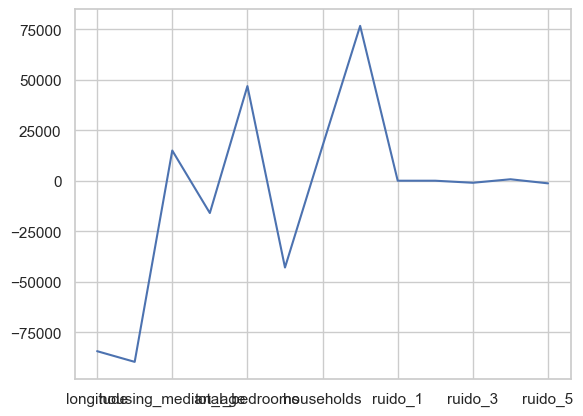

In [16]:
# 4. Grafica los 10 coeficientes más importantes
coef_serie.plot()

---
## 🏠 EJERCICIO PARA LA PRÓXIMA SESIÓN: Ridge vs. Lasso

Has visto cómo funciona Lasso. Ahora te toca a ti comparar su comportamiento con el de Ridge.

**Tu misión:**
1.  **Entrena un modelo `RidgeCV`**. Al igual que `LassoCV`, encontrará el mejor `alpha` por sí mismo. Utiliza los mismos datos de entrenamiento (`X_train`, `y_train`).
2.  **Evalúa su rendimiento** en el conjunto de test y obtén su RMSE.
3.  **Extrae los coeficientes** del modelo Ridge entrenado.
4.  **Cuenta cuántos coeficientes son exactamente cero** en el modelo Ridge.
5.  **Crea un gráfico de barras** que compare los 15 coeficientes más grandes (en valor absoluto) de Lasso y Ridge.

**--- Preguntas para la Reflexión ---**

**Responde a estas preguntas en una celda de texto (Markdown) al final de tu notebook:**

1.  **Rendimiento:** ¿Qué modelo ha obtenido un mejor RMSE en el conjunto de test, Lasso o Ridge? ¿Fue la diferencia muy grande?
2.  **Selección de Características:** ¿Cuántas variables eliminó Ridge (coeficiente = 0)? Compara este número con el de Lasso. ¿Qué te dice esto sobre la diferencia fundamental entre ambas técnicas?
3.  **Decisión de Negocio:** Imagina que tu jefe te pide dos cosas:
    a) El modelo más preciso posible.
    b) Una lista clara y corta de los 5 factores más importantes que influyen en el precio de una casa para crear un panfleto para vendedores.

    ¿Qué modelo (Lasso o Ridge) usarías para cada petición? Justifica tu respuesta.

In [ ]:
# 1. Entrena un modelo RidgeCV
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 13))
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_

np.float64(10.0)

In [27]:
# 2. Evalúa su rendimiento

y_pred_ridge = ridge_cv.predict(X_test)


In [28]:
# 3. Extrae los coeficientes
rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"   RMSE Ridge en test: {rmse_ridge_test:.2f}")


   RMSE Ridge en test: 71104.91


In [29]:
# 4. Cuenta los coeficientes que son cero
coeficientes_ridge = ridge_cv.coef_
print(f"   Total de coeficientes: {len(coeficientes_ridge)}")

# Creamos una Serie de pandas para los coeficientes
nombres_columnas = list(X.columns) + [f'Ruido_{i+1}' for i in range(5)]
serie_coeficientes_ridge = pd.Series(coeficientes_ridge, index=nombres_columnas)

   Total de coeficientes: 13


In [34]:
# 5. Crea el gráfico comparativo


### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas)*

1.  **Rendimiento:** ¿Qué modelo ha obtenido un mejor RMSE en el conjunto de test, Lasso o Ridge? ¿Fue la diferencia muy grande?

2.  **Selección de Características:** ¿Cuántas variables eliminó Ridge (coeficiente = 0)? Compara este número con el de Lasso. ¿Qué te dice esto sobre la diferencia fundamental entre ambas técnicas?

3.  **Decisión de Negocio:** Imagina que tu jefe te pide dos cosas:
    a) El modelo más preciso posible.
    b) Una lista clara y corta de los 5 factores más importantes que influyen en el precio de una casa para crear un panfleto para vendedores.

    ¿Qué modelo (Lasso o Ridge) usarías para cada petición? Justifica tu respuesta.

lasso hace suma de valores absolutos, puede dar 0 al ser valores independientes

ridge hace algo con cuadrados, un cuadrado nunca podra ser 0